In [9]:
!pip install -q pandas plotly dash dash-bootstrap-components requests

In [10]:
import time
from threading import Thread

import pandas as pd
import requests
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt

from dash import Dash, dcc, html, Input, Output
import dash_bootstrap_components as dbc

In [11]:
class MSPDemoData:

    DATA = {
        "Все округа (РФ)": {
            "Микропредприятия": 5_820_000,
            "Малые предприятия": 190_000,
            "Средние предприятия": 18_000,
            "Итого МСП": 6_028_000,
            "Юридические лица": 1_850_000,
            "ИП": 4_178_000,
        },
        "Центральный": {
            "Микропредприятия": 1_750_000,
            "Малые предприятия": 58_000,
            "Средние предприятия": 5_400,
            "Итого МСП": 1_813_400,
            "Юридические лица": 620_000,
            "ИП": 1_193_400,
        },
        "Приволжский": {
            "Микропредприятия": 960_000,
            "Малые предприятия": 32_000,
            "Средние предприятия": 3_100,
            "Итого МСП": 995_100,
            "Юридические лица": 280_000,
            "ИП": 715_100,
        },
        "Северо-Западный": {
            "Микропредприятия": 680_000,
            "Малые предприятия": 22_000,
            "Средние предприятия": 2_100,
            "Итого МСП": 704_100,
            "Юридические лица": 230_000,
            "ИП": 474_100,
        },
        "Сибирский": {
            "Микропредприятия": 540_000,
            "Малые предприятия": 17_000,
            "Средние предприятия": 1_600,
            "Итого МСП": 558_600,
            "Юридические лица": 145_000,
            "ИП": 413_600,
        },
        "Южный": {
            "Микропредприятия": 490_000,
            "Малые предприятия": 15_000,
            "Средние предприятия": 1_400,
            "Итого МСП": 506_400,
            "Юридические лица": 125_000,
            "ИП": 381_400,
        },
        "Уральский": {
            "Микропредприятия": 420_000,
            "Малые предприятия": 14_000,
            "Средние предприятия": 1_350,
            "Итого МСП": 435_350,
            "Юридические лица": 120_000,
            "ИП": 315_350,
        },
        "Дальневосточный": {
            "Микропредприятия": 290_000,
            "Малые предприятия": 9_500,
            "Средние предприятия": 900,
            "Итого МСП": 300_400,
            "Юридические лица": 75_000,
            "ИП": 225_400,
        },
        "Северо-Кавказский": {
            "Микропредприятия": 210_000,
            "Малые предприятия": 6_500,
            "Средние предприятия": 620,
            "Итого МСП": 217_120,
            "Юридические лица": 45_000,
            "ИП": 172_120,
        },
    }

    @classmethod
    def get_dataframe(cls):
      """
      Преобразует словарь в DataFrame
      """
      rows = []

      for district, values in cls.DATA.items():
          row = {"district": district}
          row.update(values)
          rows.append(row)

      return pd.DataFrame(rows)

In [12]:

class MSPMatplotlibCharts:
    """
    Класс строит обычные статичные графики через matplotlib.

    Эти графики нужны для первичного анализа данных.
    Они не являются частью Dash-дашборда, а просто показываются
    в выводе ячейки перед запуском интерактивного приложения.
    """

    COLORS = [
        "#2563EB",
        "#16A34A",
        "#DC2626",
        "#D97706",
        "#7C3AED",
        "#0891B2",
        "#BE185D",
        "#65A30D",
    ]

    CATEGORIES = [
        "Микропредприятия",
        "Малые предприятия",
        "Средние предприятия",
    ]

    def __init__(self, summary_df):
        """
        Конструктор получает общую таблицу с данными.

        df_regions — данные только по федеральным округам.
        df_total — строка с общей статистикой по РФ.
        """
        self.df = summary_df.copy()

        self.df_regions = self.df[
            self.df["district"] != "Все округа (РФ)"
        ].copy()

        self.df_total = self.df[
            self.df["district"] == "Все округа (РФ)"
        ].copy()

    def show_all(self):
        """
        Показывает все matplotlib-графики по очереди.
        """
        self._show_total_by_district()
        self._show_category_pie()
        self._show_ul_ip_chart()
        self._show_category_percent_chart()

    def _show_total_by_district(self):
        """
        Строит горизонтальную диаграмму:
        общее количество МСП по федеральным округам.
        """
        df = self.df_regions.sort_values("Итого МСП")

        fig, ax = plt.subplots(figsize=(12, 6))

        bars = ax.barh(
            df["district"],
            df["Итого МСП"] / 1000,
            color=self.COLORS[:len(df)],
            edgecolor="white",
        )

        for bar in bars:
            width = bar.get_width()

            ax.text(
                width + 5,
                bar.get_y() + bar.get_height() / 2,
                f"{width:,.0f} тыс.",
                va="center",
                fontsize=9,
            )

        ax.set_xlabel("тыс. субъектов")
        ax.set_title("МСП по федеральным округам")
        ax.spines[["top", "right"]].set_visible(False)

        plt.tight_layout()
        plt.show()

    def _show_category_pie(self):
        """
        Строит круговую диаграмму:
        структура МСП по категориям.
        """
        if not self.df_total.empty:
            total_row = self.df_total.iloc[0]
        else:
            total_row = self.df_regions.sum(numeric_only=True)

        values = [total_row[category] for category in self.CATEGORIES]

        fig, ax = plt.subplots(figsize=(7, 7))

        ax.pie(
            values,
            labels=self.CATEGORIES,
            autopct="%1.1f%%",
            colors=self.COLORS[:3],
            wedgeprops={
                "edgecolor": "white",
                "linewidth": 2,
            },
        )

        ax.set_title("Структура МСП по категориям")

        plt.tight_layout()
        plt.show()

    def _show_ul_ip_chart(self):
        """
        Строит столбчатую диаграмму:
        юридические лица и ИП по округам.
        """
        df = self.df_regions.sort_values("Итого МСП", ascending=False)

        x = np.arange(len(df))

        ul_values = df["Юридические лица"].values / 1000
        ip_values = df["ИП"].values / 1000

        fig, ax = plt.subplots(figsize=(12, 6))

        ax.bar(
            x,
            ul_values,
            width=0.5,
            label="ЮЛ",
            color="#6366F1",
        )

        ax.bar(
            x,
            ip_values,
            width=0.5,
            bottom=ul_values,
            label="ИП",
            color="#EC4899",
        )

        ax.set_xticks(x)
        ax.set_xticklabels(
            df["district"],
            rotation=25,
            ha="right",
        )

        ax.set_ylabel("тыс. субъектов")
        ax.set_title("ЮЛ и ИП по округам")
        ax.legend()
        ax.spines[["top", "right"]].set_visible(False)

        plt.tight_layout()
        plt.show()

    def _show_category_percent_chart(self):
      """
      Строит накопленную диаграмму:
      доля микро, малых и средних предприятий по округам.
      """
      # reset_index нужен, чтобы индексы снова стали 0, 1, 2...
      df = self.df_regions.copy().reset_index(drop=True)

      # Считаем сумму по категориям для каждого округа
      total = df[self.CATEGORIES].sum(axis=1).replace(0, pd.NA)

      x = np.arange(len(df))

      fig, ax = plt.subplots(figsize=(12, 6))

      # bottom храним как обычный numpy-массив, чтобы не было ошибок с индексами pandas
      bottom = np.zeros(len(df))

      for index, category in enumerate(self.CATEGORIES):
          values = (df[category] / total * 100).fillna(0).round(1).to_numpy()

          ax.bar(
              x,
              values,
              width=0.6,
              bottom=bottom,
              label=category,
              color=self.COLORS[index],
          )

          for i, value in enumerate(values):
              if value > 3:
                  ax.text(
                      x[i],
                      bottom[i] + value / 2,
                      f"{value:.1f}%",
                      ha="center",
                      va="center",
                      fontsize=8,
                      color="white",
                      fontweight="bold",
                  )

          bottom = bottom + values

      ax.set_xticks(x)
      ax.set_xticklabels(
          df["district"],
          rotation=25,
          ha="right",
      )

      ax.set_ylabel("%")
      ax.set_ylim(0, 100)
      ax.set_title("Доля категорий МСП по округам")
      ax.legend()
      ax.spines[["top", "right"]].set_visible(False)

      plt.tight_layout()
      plt.show()

In [13]:
class MSPDashboard:
    """
    Создаёт и запускает Dash-дашборд по данным МСП
    """

    COLORS = {
        "primary": "#1E40AF",
        "micro": "#3B82F6",
        "small": "#10B981",
        "medium": "#F59E0B",
        "ul": "#6366F1",
        "ip": "#EC4899",
        "bg": "#F8FAFC",
        "muted": "#64748B",
    }

    CATEGORIES = [
        "Микропредприятия",
        "Малые предприятия",
        "Средние предприятия",
    ]

    def __init__(self, summary_df):
        """
        Конструктор получает таблицу с данными и подготавливает приложение.

        summary_df — исходная таблица со всеми данными
        df_regions — таблица только по округам, без общей строки РФ
        """
        self.df = summary_df.copy()

        self.df_regions = self.df[
            self.df["district"] != "Все округа (РФ)"
        ].copy()

        self.category_colors = {
            "Микропредприятия": self.COLORS["micro"],
            "Малые предприятия": self.COLORS["small"],
            "Средние предприятия": self.COLORS["medium"],
        }

        self.app = Dash(__name__, external_stylesheets=[dbc.themes.FLATLY])

        self._build_layout()
        self._register_callbacks()

    def _format_number(self, value):
        """
        Форматирует число с пробелами между разрядами

        Например:
        6028000 -> 6 028 000
        """
        return f"{int(value):,}".replace(",", " ")

    def _create_kpi_card(self, title, value, color):
        """
        Создаёт одну карточку KPI

        Такие карточки используются в верхней части дашборда
        """
        return dbc.Card(
            dbc.CardBody([
                html.H6(
                    title,
                    style={
                        "color": self.COLORS["muted"],
                        "fontSize": "0.8rem",
                    },
                ),
                html.H3(
                    value,
                    style={
                        "color": color,
                        "fontWeight": "800",
                    },
                ),
            ]),
            style={
                "borderRadius": "12px",
                "border": "none",
                "boxShadow": "0 4px 16px rgba(0,0,0,0.06)",
                "textAlign": "center",
            },
        )

    def _build_layout(self):
        """
        Создаёт внешний вид дашборда.

        Здесь задаются:
        - заголовок;
        - KPI-карточки;
        - фильтр по округу;
        - выбор категорий;
        - места для четырёх графиков
        """
        district_options = [{"label": "Все", "value": "ALL"}]

        for district in self.df_regions["district"].unique():
            district_options.append({
                "label": district,
                "value": district,
            })

        category_options = [
            {"label": " Микро", "value": "Микропредприятия"},
            {"label": " Малые", "value": "Малые предприятия"},
            {"label": " Средние", "value": "Средние предприятия"},
        ]

        self.app.layout = dbc.Container(
            [
                html.H4(
                    "Субъекты МСП России",
                    className="mt-4 mb-3",
                    style={
                        "color": self.COLORS["primary"],
                        "fontWeight": "800",
                    },
                ),

                dbc.Row(
                    [
                        dbc.Col(
                            self._create_kpi_card(
                                "Всего МСП",
                                self._format_number(self.df_regions["Итого МСП"].sum()),
                                self.COLORS["primary"],
                            ),
                            md=3,
                        ),
                        dbc.Col(
                            self._create_kpi_card(
                                "ИП",
                                self._format_number(self.df_regions["ИП"].sum()),
                                self.COLORS["ip"],
                            ),
                            md=3,
                        ),
                        dbc.Col(
                            self._create_kpi_card(
                                "Юр. лиц",
                                self._format_number(self.df_regions["Юридические лица"].sum()),
                                self.COLORS["ul"],
                            ),
                            md=3,
                        ),
                        dbc.Col(
                            self._create_kpi_card(
                                "Микропредприятий",
                                self._format_number(self.df_regions["Микропредприятия"].sum()),
                                self.COLORS["micro"],
                            ),
                            md=3,
                        ),
                    ],
                    className="g-3 mb-4",
                ),

                dbc.Row(
                    [
                        dbc.Col(
                            [
                                html.Label("Округ"),
                                dcc.Dropdown(
                                    id="district-dropdown",
                                    options=district_options,
                                    value="ALL",
                                    clearable=False,
                                ),
                            ],
                            md=4,
                        ),
                        dbc.Col(
                            [
                                html.Label("Категории"),
                                dcc.Checklist(
                                    id="category-checklist",
                                    options=category_options,
                                    value=self.CATEGORIES,
                                    inline=True,
                                    inputStyle={
                                        "marginRight": "4px",
                                        "marginLeft": "12px",
                                    },
                                ),
                            ],
                            md=8,
                        ),
                    ],
                    className="mb-4",
                ),

                dbc.Row(
                    [
                        dbc.Col(dcc.Graph(id="graph-total"), md=8),
                        dbc.Col(dcc.Graph(id="graph-categories"), md=4),
                    ],
                    className="mb-3",
                ),

                dbc.Row(
                    [
                        dbc.Col(dcc.Graph(id="graph-ul-ip"), md=6),
                        dbc.Col(dcc.Graph(id="graph-percent"), md=6),
                    ]
                ),
            ],
            fluid=True,
            style={
                "background": self.COLORS["bg"],
                "minHeight": "100vh",
            },
        )

    def _register_callbacks(self):
        """
        Регистрирует callback Dash

        Callback автоматически обновляет графики,
        когда пользователь меняет округ или категории
        """
        @self.app.callback(
            Output("graph-total", "figure"),
            Output("graph-categories", "figure"),
            Output("graph-ul-ip", "figure"),
            Output("graph-percent", "figure"),
            Input("district-dropdown", "value"),
            Input("category-checklist", "value"),
        )
        def update_graphs(selected_district, selected_categories):
            return self._make_figures(selected_district, selected_categories)

    def _filter_data(self, selected_district):
        """
        Возвращает данные для выбранного округа

        Если выбран вариант 'Все', возвращаются все округа
        """
        if selected_district == "ALL":
            return self.df_regions.copy()

        return self.df_regions[
            self.df_regions["district"] == selected_district
        ].copy()

    def _make_figures(self, selected_district, selected_categories):
        """
        Создаёт четыре графика для дашборда

        selected_district — выбранный округ
        selected_categories — выбранные категории МСП
        """
        df = self._filter_data(selected_district)

        if not selected_categories:
            selected_categories = self.CATEGORIES

        g1 = self._make_total_bar_chart(df)
        g2 = self._make_category_pie_chart(df, selected_categories)
        g3 = self._make_ul_ip_chart(df)
        g4 = self._make_percent_chart(df, selected_categories)

        return g1, g2, g3, g4

    def _make_total_bar_chart(self, df):
        """
        Строит горизонтальную диаграмму с общим количеством МСП
        """
        fig = px.bar(
            df.sort_values("Итого МСП"),
            x="Итого МСП",
            y="district",
            orientation="h",
            color="district",
            template="plotly_white",
            title="Всего МСП",
            labels={
                "Итого МСП": "Количество субъектов МСП",
                "district": "Округ",
            },
        )

        fig.update_layout(
            showlegend=False,
            margin=dict(l=10, r=10, t=40, b=10),
        )

        return fig

    def _make_category_pie_chart(self, df, selected_categories):
        """
        Строит круговую диаграмму по выбранным категориям МСП
        """
        fig = go.Figure(
            go.Pie(
                labels=selected_categories,
                values=[df[col].sum() for col in selected_categories],
                hole=0.4,
                marker_colors=[
                    self.category_colors[col]
                    for col in selected_categories
                ],
            )
        )

        fig.update_layout(
            title="Категории",
            margin=dict(l=10, r=10, t=40, b=10),
        )

        return fig

    def _make_ul_ip_chart(self, df):
        """
        Строит столбчатую диаграмму по юридическим лицам и ИП
        """
        fig = go.Figure()

        fig.add_trace(
            go.Bar(
                x=df["district"],
                y=df["Юридические лица"],
                name="ЮЛ",
                marker_color=self.COLORS["ul"],
            )
        )

        fig.add_trace(
            go.Bar(
                x=df["district"],
                y=df["ИП"],
                name="ИП",
                marker_color=self.COLORS["ip"],
            )
        )

        fig.update_layout(
            barmode="group",
            template="plotly_white",
            title="ЮЛ и ИП",
            xaxis_tickangle=-30,
            margin=dict(l=10, r=10, t=40, b=80),
        )

        return fig

    def _make_percent_chart(self, df, selected_categories):
        """
        Строит диаграмму с долями категорий МСП в процентах
        """
        fig = go.Figure()

        total = df[selected_categories].sum(axis=1).replace(0, pd.NA)

        for category in selected_categories:
            percent_values = (df[category] / total * 100).fillna(0).round(1)

            fig.add_trace(
                go.Bar(
                    x=df["district"],
                    y=percent_values,
                    name=category,
                    marker_color=self.category_colors[category],
                )
            )

        fig.update_layout(
            barmode="stack",
            template="plotly_white",
            title="Доля %",
            yaxis_ticksuffix="%",
            xaxis_tickangle=-30,
            margin=dict(l=10, r=10, t=40, b=80),
        )

        return fig

    def run_colab(self, port=8050, height=800):
        """
        Запускает Dash-приложение в Google Colab

        Dash-сервер запускается в отдельном потоке
        """
        def run_server():
            self.app.run(
                host="0.0.0.0",
                port=port,
                debug=False,
                use_reloader=False,
            )

        thread = Thread(target=run_server, daemon=True)
        thread.start()

        for _ in range(30):
            try:
                response = requests.get(
                    f"http://127.0.0.1:{port}",
                    timeout=1,
                )

                if response.status_code == 200:
                    print(f"Dash server is ready on port {port}")
                    break

            except Exception:
                time.sleep(1)

        from google.colab import output
        output.serve_kernel_port_as_iframe(port, height=height)

In [14]:
summary_df = MSPDemoData.get_dataframe()
display(summary_df)

,district,Микропредприятия,Малые предприятия,Средние предприятия,Итого МСП,Юридические лица,ИП
0,Все округа (РФ),5820000,190000,18000,6028000,1850000,4178000
1,Центральный,1750000,58000,5400,1813400,620000,1193400
2,Приволжский,960000,32000,3100,995100,280000,715100
3,Северо-Западный,680000,22000,2100,704100,230000,474100
4,Сибирский,540000,17000,1600,558600,145000,413600
5,Южный,490000,15000,1400,506400,125000,381400
6,Уральский,420000,14000,1350,435350,120000,315350
7,Дальневосточный,290000,9500,900,300400,75000,225400
8,Северо-Кавказский,210000,6500,620,217120,45000,172120


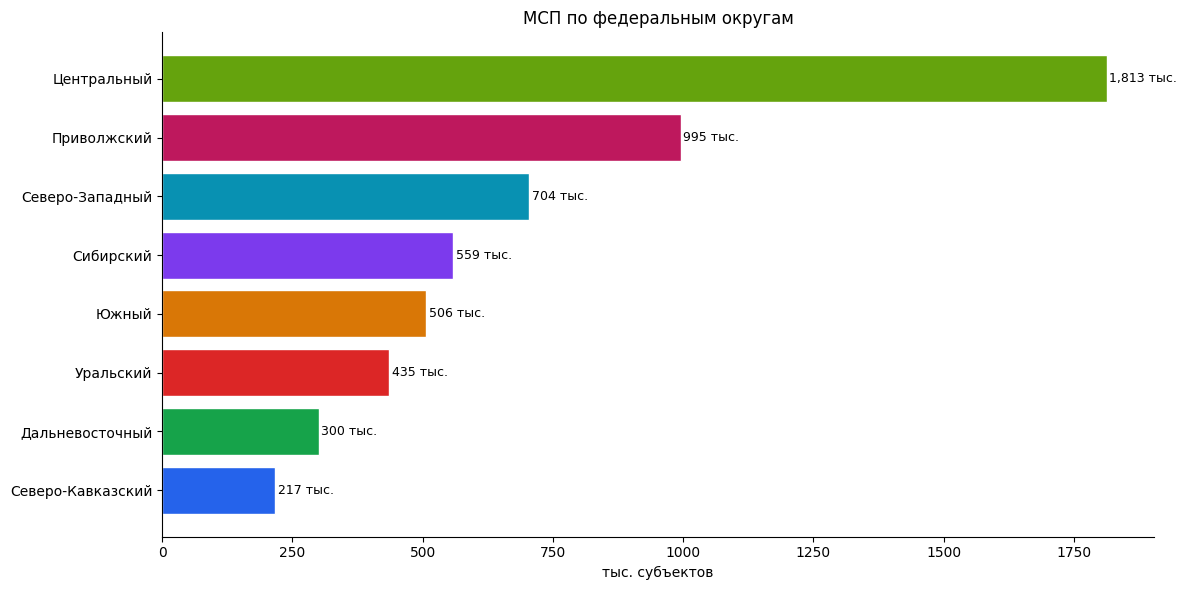

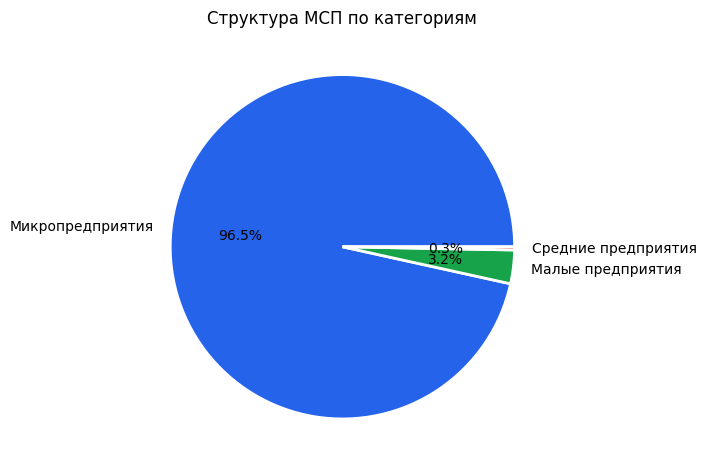

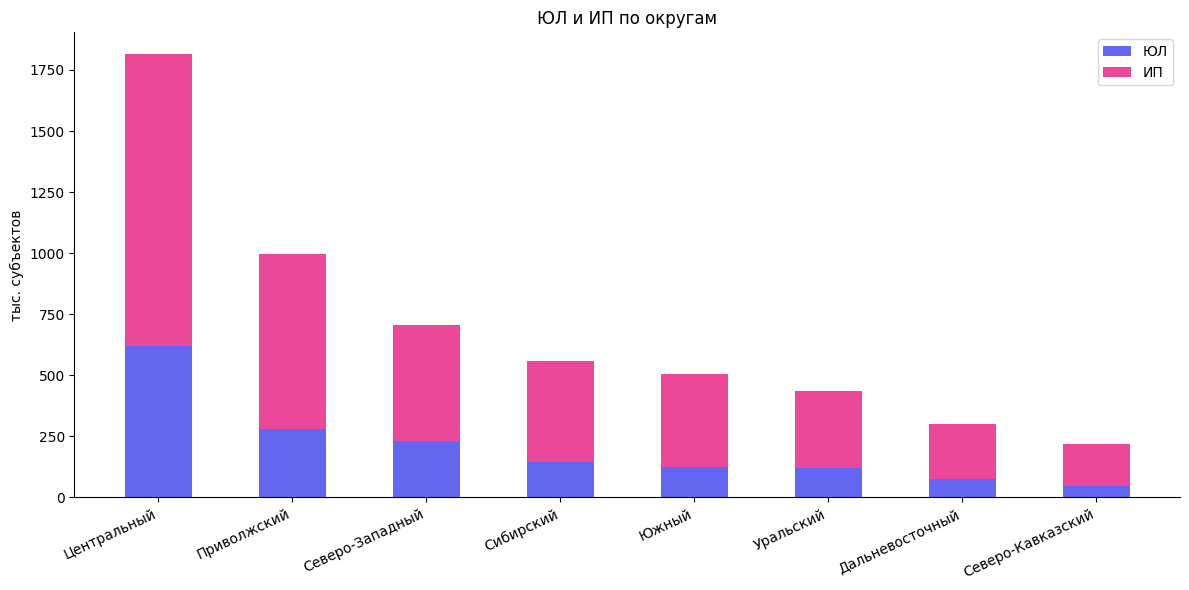

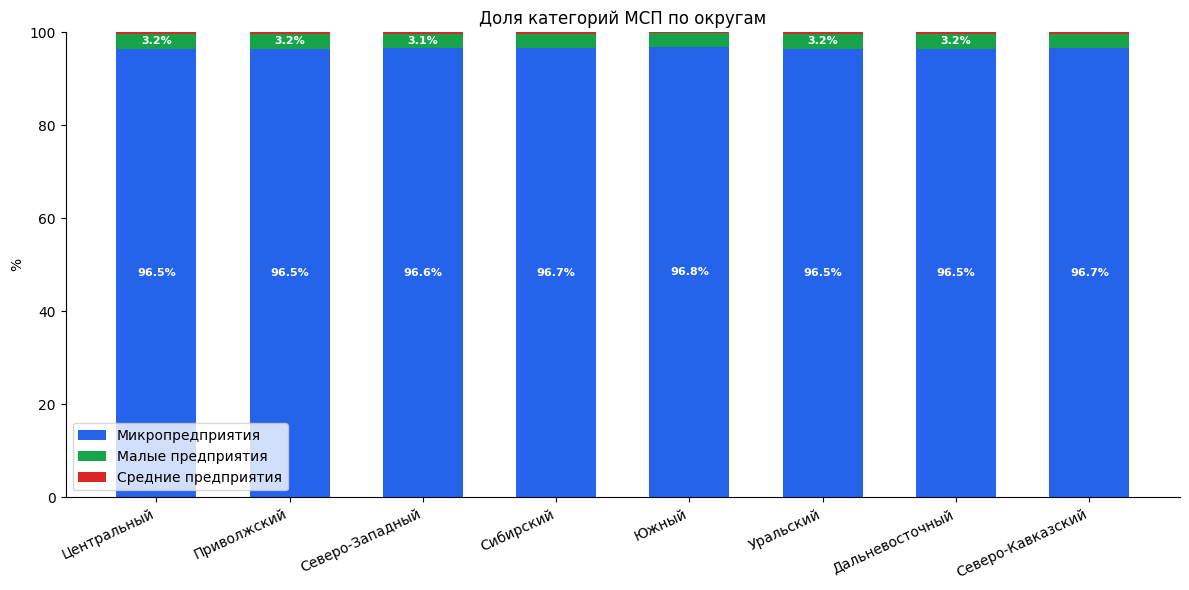

In [15]:
# Статичные графики matplotlib
matplotlib_charts = MSPMatplotlibCharts(summary_df)
matplotlib_charts.show_all()

In [16]:
# Интерактивный Dash-дашборд
dashboard = MSPDashboard(summary_df)
dashboard.run_colab(port=8050, height=800)

Dash is running on http://0.0.0.0:8050/



INFO:dash.dash:Dash is running on http://0.0.0.0:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 8050 is in use by another program. Either identify and stop that program, or start the server with a different port.
INFO:werkzeug:127.0.0.1 - - [27/May/2026 00:22:01] "GET / HTTP/1.1" 200 -


Dash server is ready on port 8050


<IPython.core.display.Javascript object>